In [1]:
# Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS

#from autoconf import conf

#conf.instance.push(
    #new_path="/home/joao/Documents/Research/4_sys_analysis/config/", output_path="/home/joao/Documents/Research/4_sys_analysis/output_config/"
#)


from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

from os import path
import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline

/home/joao/Documents/Research/4_sys_analysis
Working Directory has been set to `/home/joao/Documents/Research/4_sys_analysis`


2021-07-16 19:57:52,162 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2021-07-16 19:57:52,507 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autoarray/config
2021-07-16 19:57:52,572 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2021-07-16 19:57:52,627 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


In [2]:
# Img blocks Paths
imgblocks_paths = "./imgblocks/"
img_path = "imgblock1.fits"

In [3]:
image = al.Array2D.from_fits(
    file_path=imgblocks_paths+img_path, pixel_scales=0.1, hdu=1
)

In [4]:
point_dict = al.PointDict.from_json(
    file_path="point_dict.json"
)

In [5]:
point_dict.positions_list

[Grid2DIrregular([[-0.9189696,  1.4900341],
                  [-1.5586632,  0.6699659],
                  [-0.5701928, -1.4035424]])]

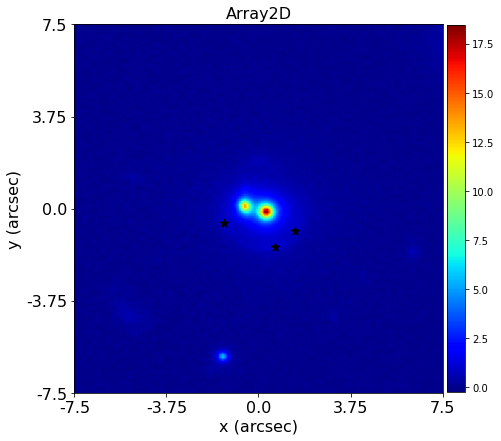

In [6]:
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)

array_plotter = aplt.Array2DPlotter(array=image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

In [7]:
lens = af.Model(al.Galaxy, redshift=0.3440, mass=al.mp.EllIsothermal)
source = af.Model(al.Galaxy, redshift=1.0, point_0=al.ps.Point)

model = af.Collection(galaxies=af.Collection(lens=lens, source=source))

In [8]:
grid = al.Grid2D.uniform(
    shape_native=image.shape_native, pixel_scales=image.pixel_scales
)

positions_solver = al.PositionsSolver(grid=grid, pixel_scale_precision=0.025)

In [9]:
search = af.DynestyStatic(
    path_prefix=imgblocks_paths,
    name="mass[sie]_source[point]",
    unique_tag="sys1",
    nlive=50,
    number_of_cores=4,
)

2021-07-16 19:57:53,690 - mass[sie]_source[point] - INFO - Creating search


In [10]:
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)

In [11]:
result = search.fit(model=model, analysis=analysis)

2021-07-16 19:57:53,868 - mass[sie]_source[point] - INFO - Starting search
2021-07-16 19:57:53,876 - mass[sie]_source[point] - INFO - Saving path info
2021-07-16 19:57:53,919 - mass[sie]_source[point] - INFO - Not complete. Starting non-linear search.
2021-07-16 19:57:53,920 - mass[sie]_source[point] - INFO - number_of_cores == 4...
2021-07-16 19:57:53,921 - mass[sie]_source[point] - WARNING - ...using SneakyPool. This copies the likelihood functionto each process on instantiation to avoid copying multipletimes.
2021-07-16 19:57:53,922 - process 0 - INFO - created
2021-07-16 19:57:53,924 - process 1 - INFO - created
2021-07-16 19:57:53,925 - process 2 - INFO - created
2021-07-16 19:57:53,948 - process 3 - INFO - created
2021-07-16 19:57:53,998 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior limits and other constraints.
2021-07-16 19:57:55,058 - mass[sie]_source[point] - INFO - No Dynesty samples found, beginning new non-linear 

580it [02:01,  4.79it/s, +50 | bound: 70 | nc: 1 | ncall: 5055 | eff(%): 12.463 | loglstar:   -inf < -4.245 <    inf | logz: -19.885 +/-  0.590 | dlogz:  0.811 >  0.059]   

2021-07-16 19:59:56,281 - mass[sie]_source[point] - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).



1127it [02:44,  6.86it/s, +50 | bound: 166 | nc: 1 | ncall: 9148 | eff(%): 12.866 | loglstar:   -inf <  9.768 <    inf | logz: -9.683 +/-  0.848 | dlogz:  0.001 >  0.059]


2021-07-16 20:02:41,285 - mass[sie]_source[point] - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


1127it [00:00, 668313.39it/s, +50 | bound: 166 | nc: 1 | ncall: 9148 | eff(%): 12.866 | loglstar:   -inf <  9.768 <    inf | logz: -9.683 +/-  0.848 | dlogz:  0.001 >  0.059]


2021-07-16 20:02:42,165 - mass[sie]_source[point] - INFO - 15000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-07-16 20:02:42,765 - mass[sie]_source[point] - INFO - 20000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-07-16 20:02:53,265 - mass[sie]_source[point] - INFO - Removing zip file


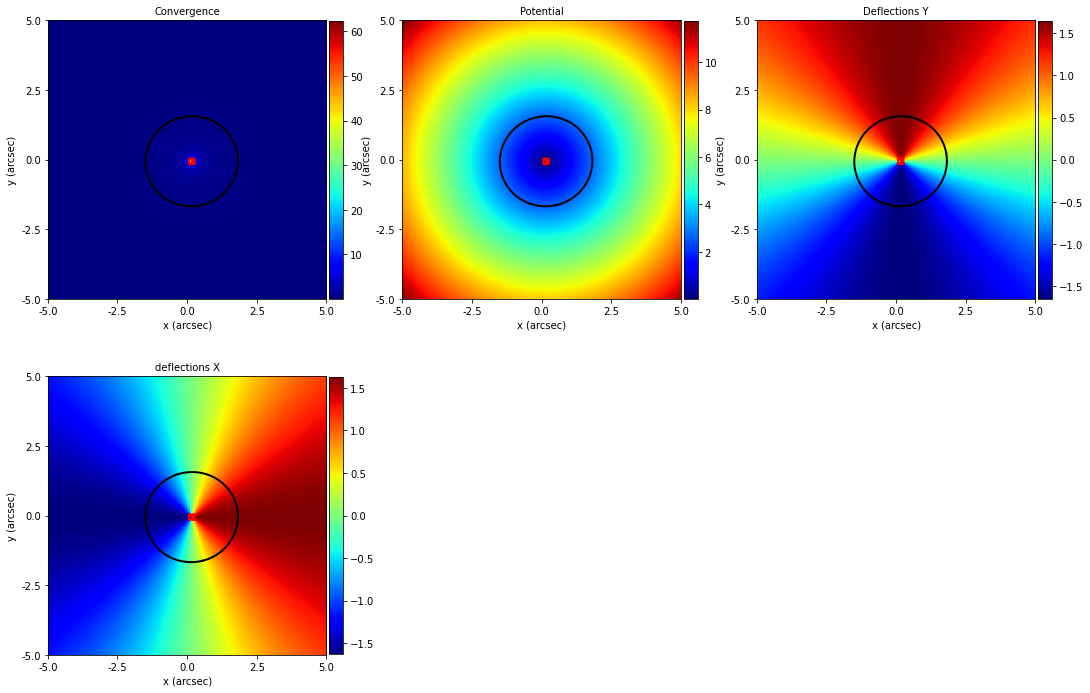

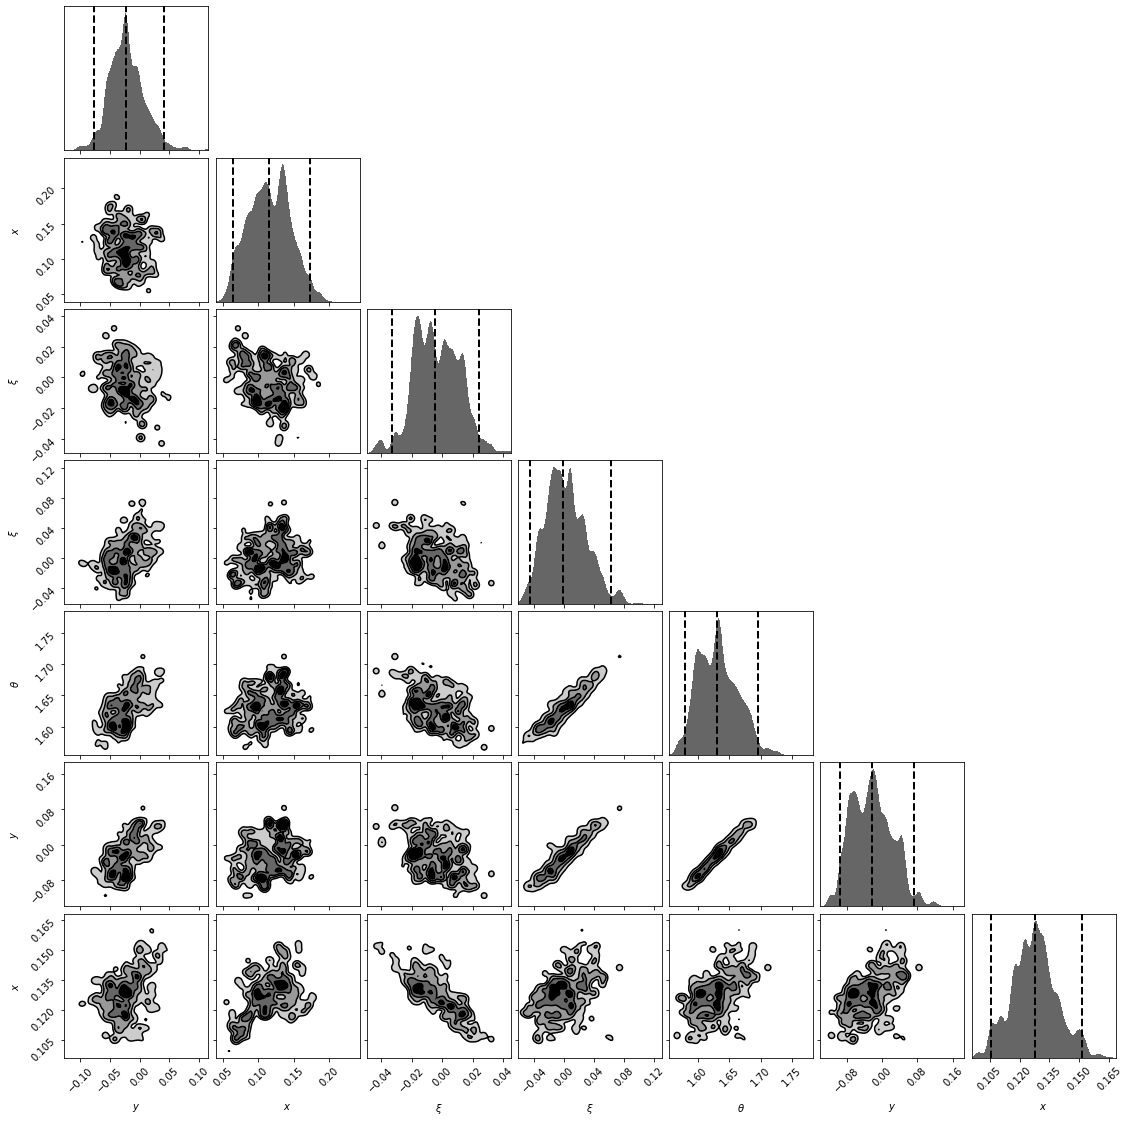

In [12]:
print(result.max_log_likelihood_instance)

tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer, grid=result.grid
)
tracer_plotter.subplot_tracer()

dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()